## EDA and OLS-based MMM Modeling

In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error,r2_score
from scipy.optimize import minimize
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the dataset
df = pd.read_excel('Case_Study_Input_File.xlsx', sheet_name='model_data')

# Drop spend-related columns except 'ventes_avenue_spends_mn'
spend_columns = [col for col in df.columns if 'spend' in col.lower()]
spend_columns = [col for col in spend_columns if col not in ['ventes_avenue_spends_mn', 'trade_promo_spends_mn','consumer_promo_spends_mn']]
df = df.drop(columns=spend_columns)


In [107]:
# Display the first few rows of the dataframe
df.head()

,date,kpi_val_sales_mn,vol_sales_mn,wtd_dist_max,num_dist_max,trade_promo_spends_mn,consumer_promo_spends_mn,newspaper_impressions,tv_total_grp,tv_spots,...,youtube_impressions_mn,fb_ig_clicks,fb_ig_impressions_mn,whatsapp_clicks,whatsapp_impressions_mn,jio_clicks,jio_impressions_mn,hotstar_clicks,hotstar_impressions_mn,ventes_avenue_spends_mn
0,2019-01-01,232.467056,302.394,60.339142,28.076869,6.386184,0.000000,0,300.21,592,...,0.0000,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0
1,2019-02-01,214.927168,279.889,60.897473,28.184146,6.903101,0.000000,22,397.51,1331,...,0.0000,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0
2,2019-03-01,243.621484,318.025,60.356401,28.494586,6.378913,0.000000,11,184.26,780,...,13.5788,43420,8.665885,0,0.0,0,0.0,3545,2.533335,0.0
3,2019-04-01,251.191704,328.868,58.884626,28.637880,6.807898,0.960220,0,0.00,0,...,0.0000,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0
4,2019-05-01,243.752604,318.636,60.130245,28.579280,4.139811,0.770213,0,317.83,1114,...,3.7910,0,0.000000,0,0.0,0,0.0,0,0.000000,0.0


In [108]:
#Price Calculation
df['Price']=df['kpi_val_sales_mn']/df['vol_sales_mn']


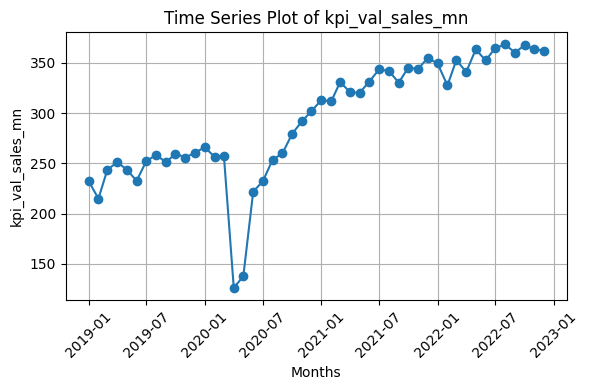

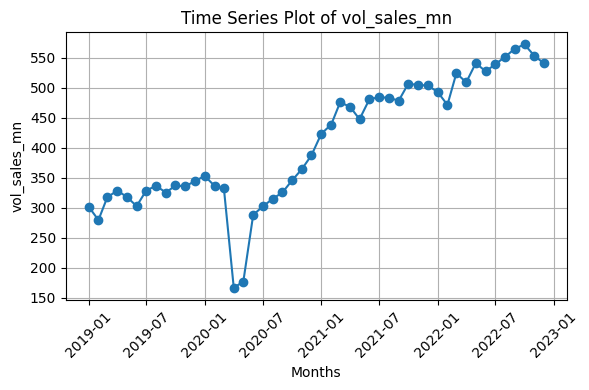

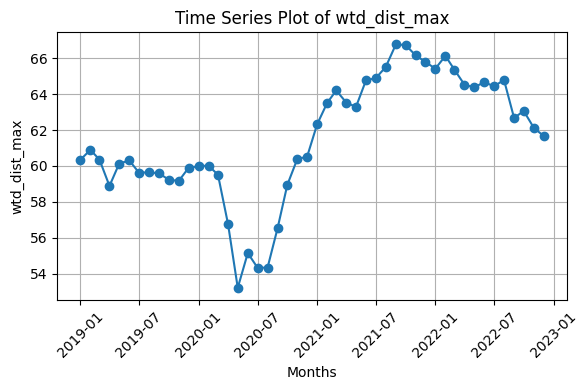

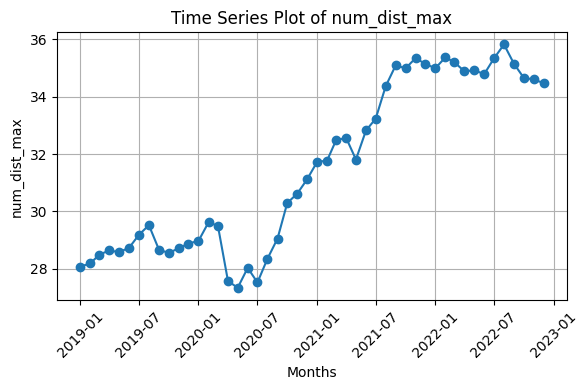

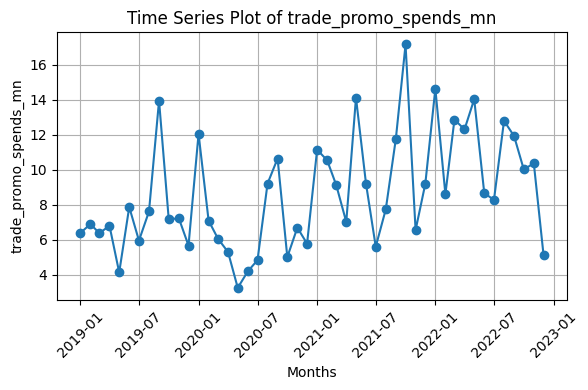

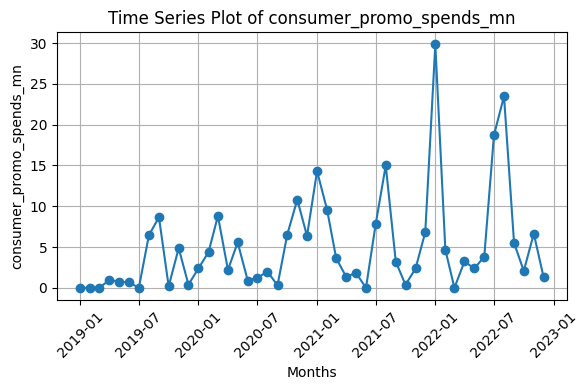

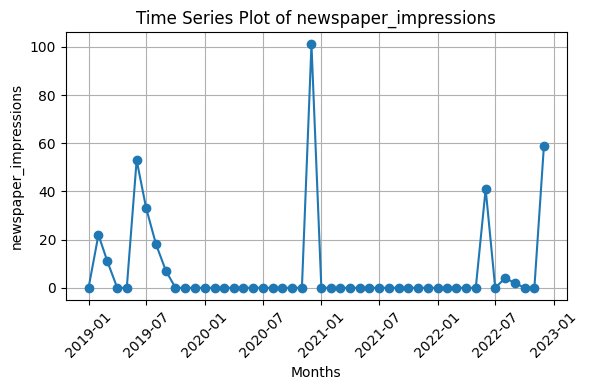

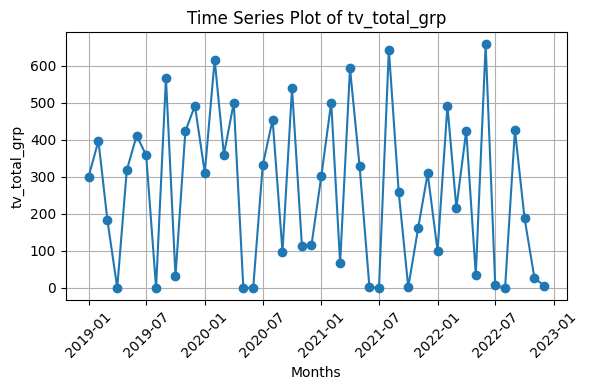

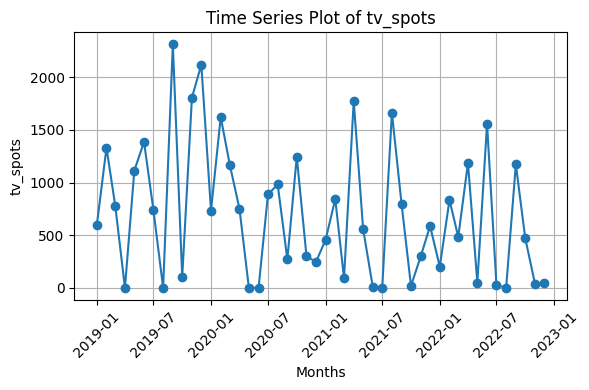

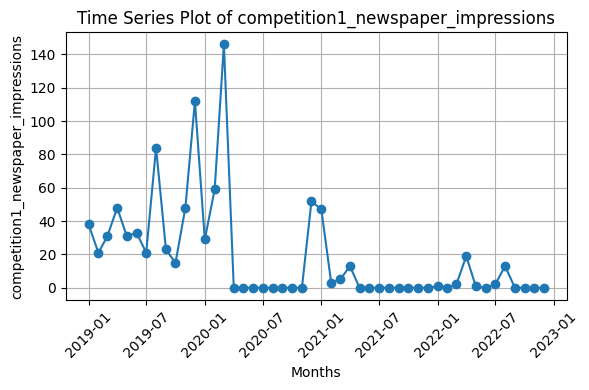

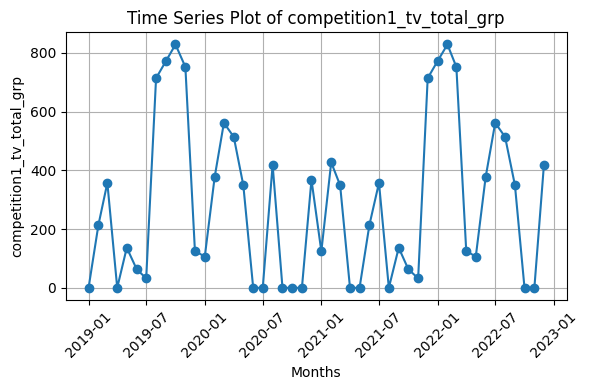

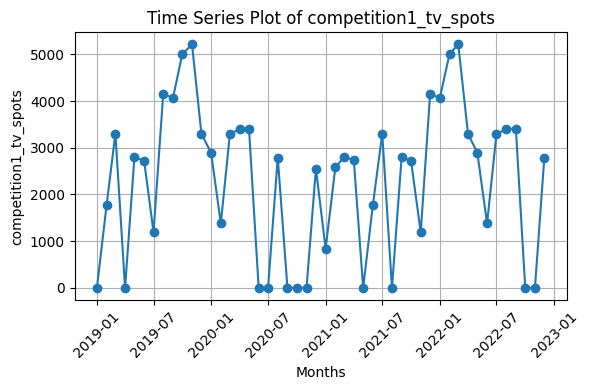

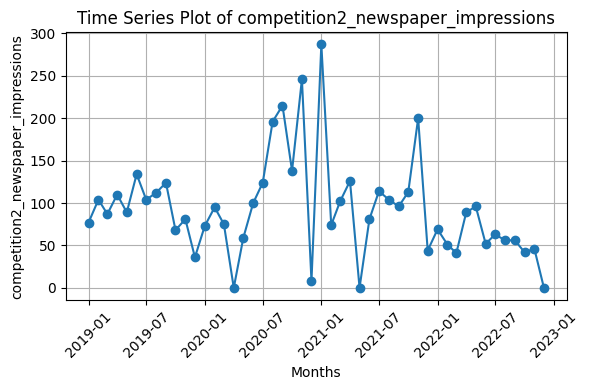

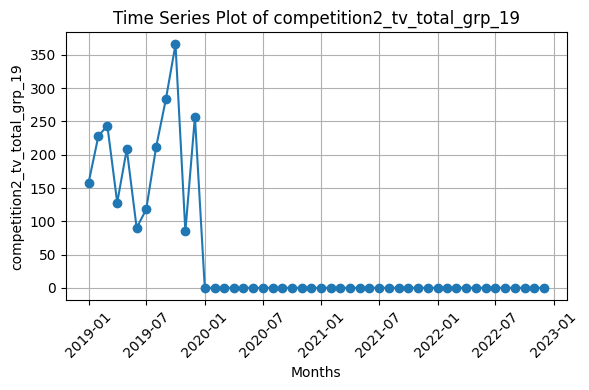

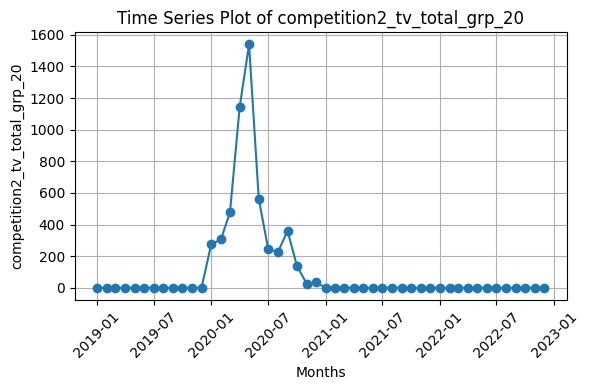

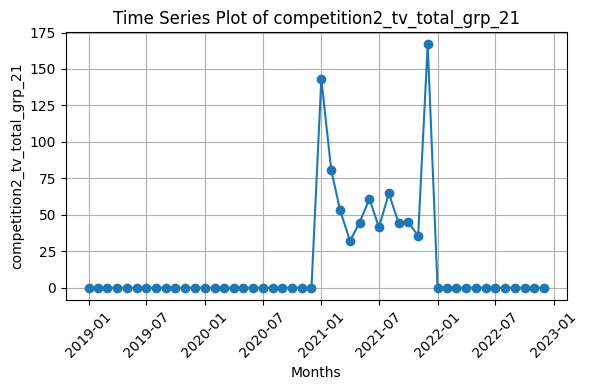

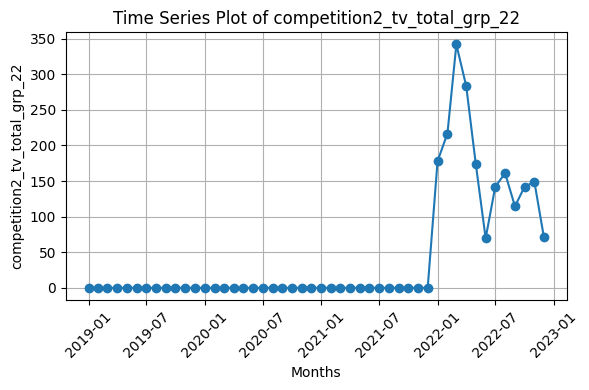

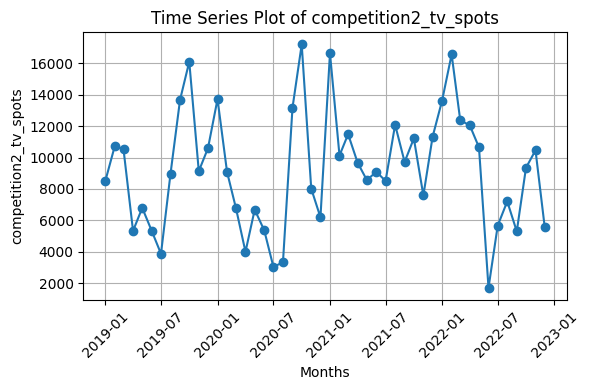

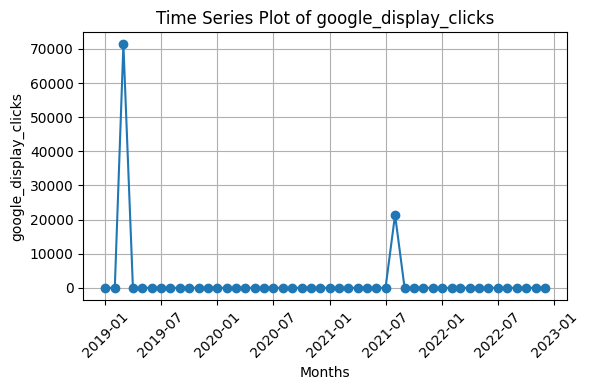

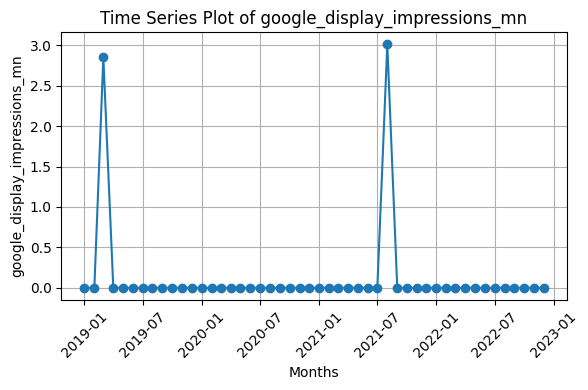

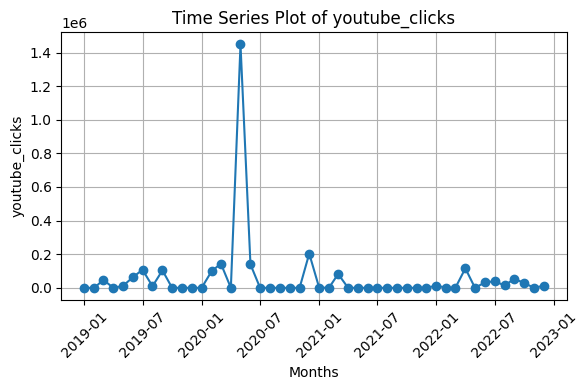

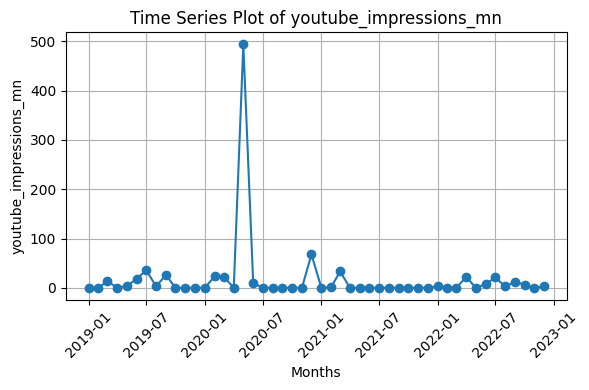

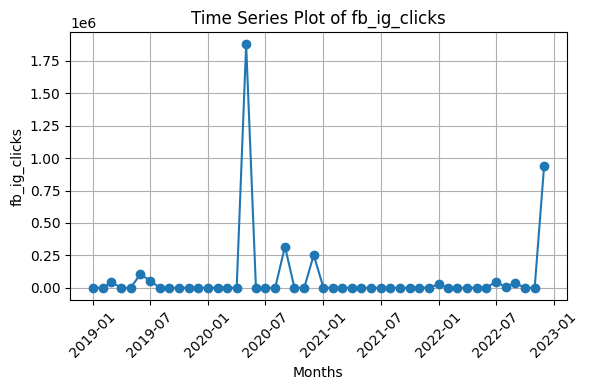

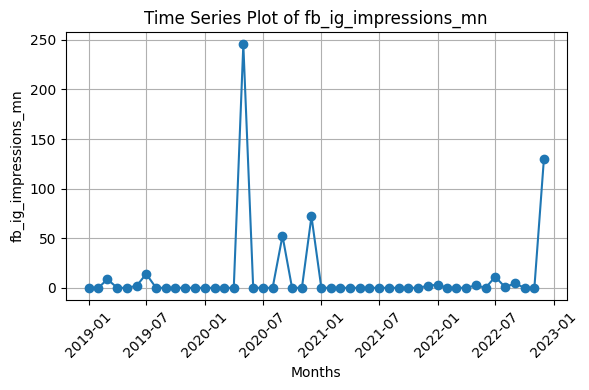

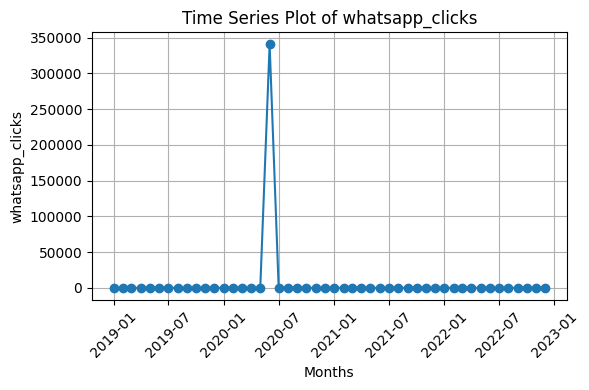

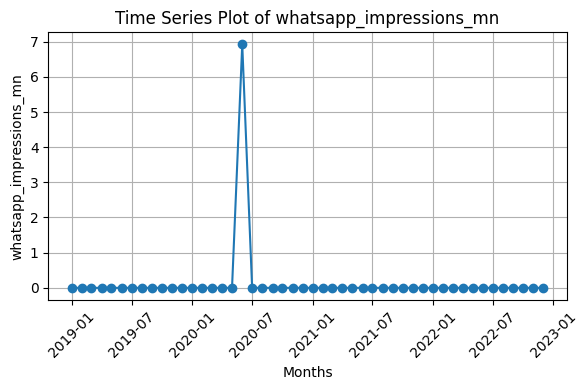

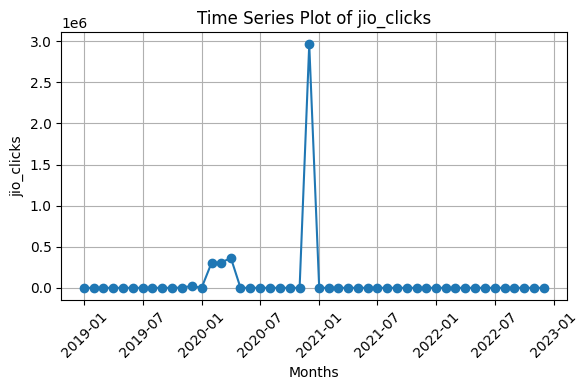

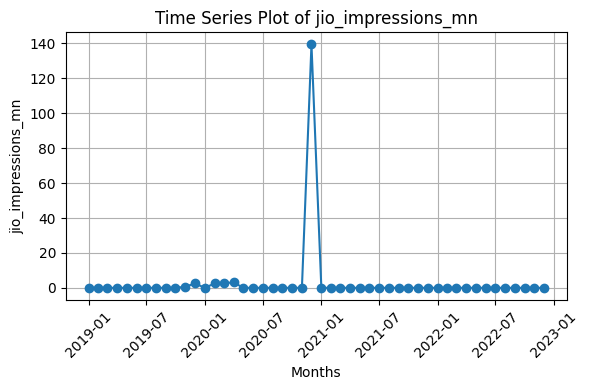

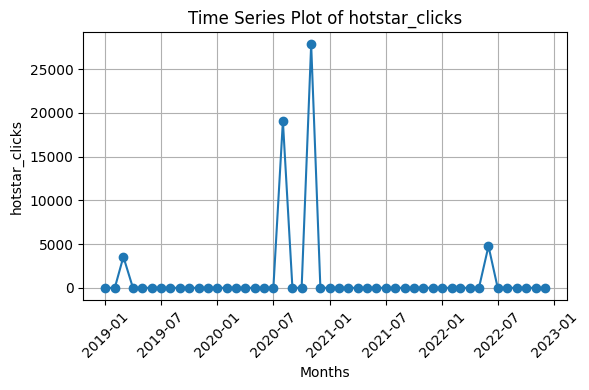

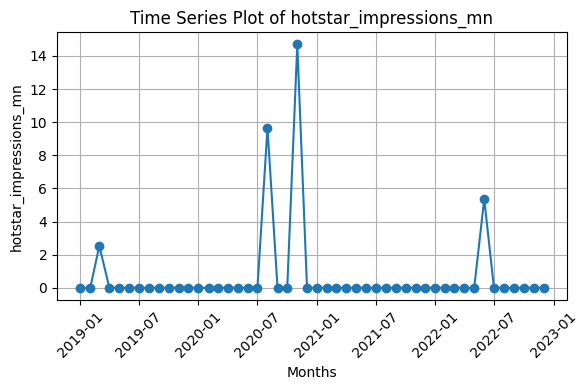

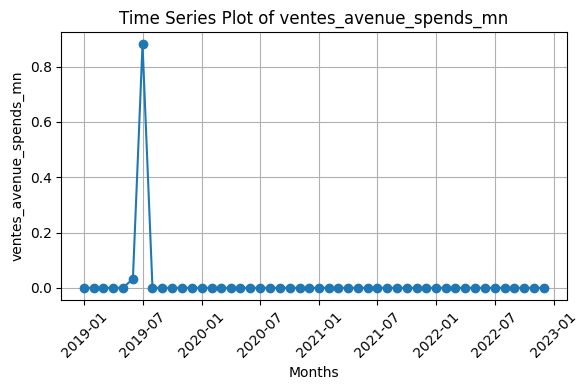

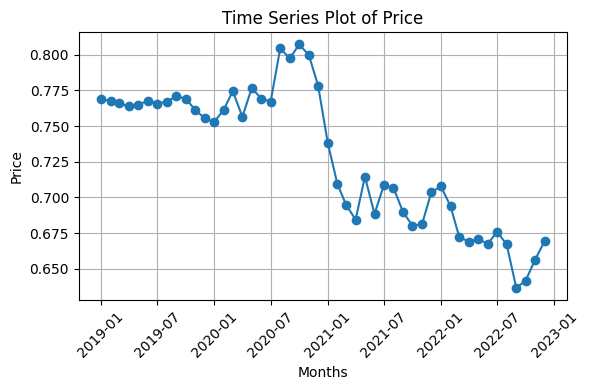

In [109]:
# List of variables to plot
variables =df.columns[1:]

# Create time series plots for each variable
for variable in variables:
    plt.figure(figsize=(6, 4))
    plt.plot(df["date"], df[variable], marker='o')
    plt.title(f'Time Series Plot of {variable}')
    plt.xlabel('Months')
    plt.ylabel(variable)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [110]:
# Exploratory Data Analysis (EDA)
# Summary statistics(First column contains months,hence not included)
df.iloc[:,1:].describe()

,kpi_val_sales_mn,vol_sales_mn,wtd_dist_max,num_dist_max,trade_promo_spends_mn,consumer_promo_spends_mn,newspaper_impressions,tv_total_grp,tv_spots,competition1_newspaper_impressions,...,fb_ig_clicks,fb_ig_impressions_mn,whatsapp_clicks,whatsapp_impressions_mn,jio_clicks,jio_impressions_mn,hotstar_clicks,hotstar_impressions_mn,ventes_avenue_spends_mn,Price
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,...,4.800000e+01,48.000000,48.000000,48.000000,4.800000e+01,48.000000,48.000000,48.000000,48.000000,48.000000
mean,293.722501,409.403229,61.553713,31.537910,8.646890,5.047986,7.31250,264.092001,700.958333,18.687500,...,7.732112e+04,11.428664,7094.145833,0.144167,8.252008e+04,3.141996,1149.041667,0.671736,0.019000,0.728408
std,59.224222,105.461019,3.482679,2.947466,3.236527,6.276398,19.40186,212.433525,639.050391,30.884243,...,3.025174e+05,41.057624,49149.684079,0.998816,4.316646e+05,20.101377,4853.979179,2.619891,0.127003,0.048510
min,126.291278,166.944000,53.203745,27.335125,3.261926,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.636675
25%,253.159445,328.149000,59.617900,28.702618,6.300529,0.862939,0.00000,34.022500,81.500000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.683641
50%,306.686986,405.809000,61.286741,31.419246,7.807479,2.797708,0.00000,301.405000,589.500000,1.500000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.745674
75%,344.195365,504.379750,64.566022,34.815109,10.767277,6.550619,0.00000,425.205000,1169.750000,29.500000,...,9.815000e+02,1.005000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.767762
max,368.123912,572.466934,66.772684,35.823721,17.150717,29.834155,101.00000,657.800000,2311.000000,146.000000,...,1.875737e+06,245.330000,340519.000000,6.920000,2.960579e+06,139.410000,27801.000000,14.690000,0.880000,0.807153


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   date                                48 non-null     datetime64[ns]
 1   kpi_val_sales_mn                    48 non-null     float64       
 2   vol_sales_mn                        48 non-null     float64       
 3   wtd_dist_max                        48 non-null     float64       
 4   num_dist_max                        48 non-null     float64       
 5   trade_promo_spends_mn               48 non-null     float64       
 6   consumer_promo_spends_mn            48 non-null     float64       
 7   newspaper_impressions               48 non-null     int64         
 8   tv_total_grp                        48 non-null     float64       
 9   tv_spots                            48 non-null     int64         
 10  competition1_newspaper_impre

In [112]:
# Check for missing values
df.isnull().sum()

date                                  0
kpi_val_sales_mn                      0
vol_sales_mn                          0
wtd_dist_max                          0
num_dist_max                          0
trade_promo_spends_mn                 0
consumer_promo_spends_mn              0
newspaper_impressions                 0
tv_total_grp                          0
tv_spots                              0
competition1_newspaper_impressions    0
competition1_tv_total_grp             0
competition1_tv_spots                 0
competition2_newspaper_impressions    0
competition2_tv_total_grp_19          0
competition2_tv_total_grp_20          0
competition2_tv_total_grp_21          0
competition2_tv_total_grp_22          0
competition2_tv_spots                 0
google_display_clicks                 0
google_display_impressions_mn         0
youtube_clicks                        0
youtube_impressions_mn                0
fb_ig_clicks                          0
fb_ig_impressions_mn                  0


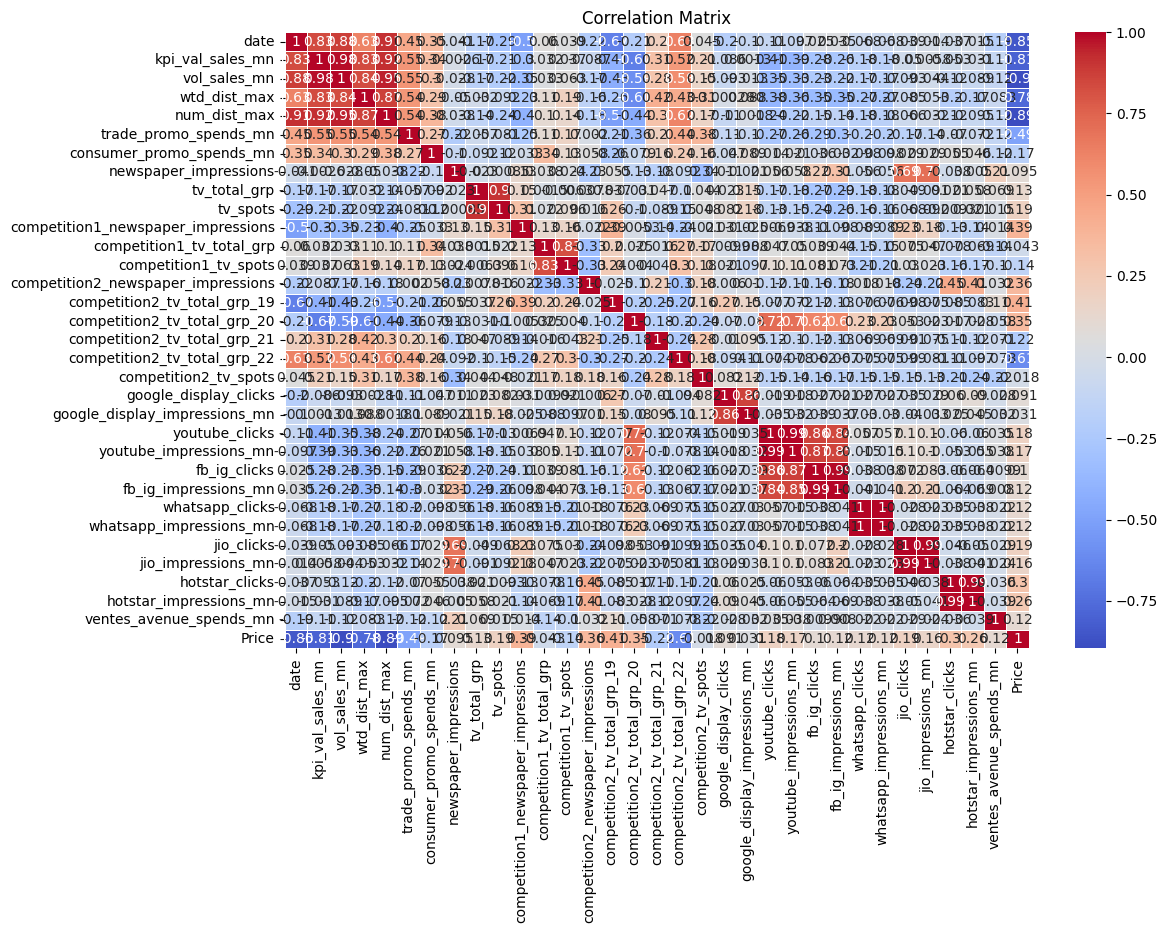

In [113]:
# Correlation matrix
correlation_matrix = df.corr()
# Plotting the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [114]:
# Correlation between sales and sales drivers
df.corr()['kpi_val_sales_mn'].sort_values(ascending=False)

kpi_val_sales_mn                      1.000000
vol_sales_mn                          0.984079
num_dist_max                          0.924293
date                                  0.833812
wtd_dist_max                          0.830255
trade_promo_spends_mn                 0.547386
competition2_tv_total_grp_22          0.523407
consumer_promo_spends_mn              0.340433
competition2_tv_total_grp_21          0.312737
competition2_tv_spots                 0.208453
competition1_tv_spots                 0.036907
competition1_tv_total_grp             0.032279
jio_impressions_mn                    0.005761
google_display_impressions_mn         0.001263
newspaper_impressions                -0.002613
hotstar_impressions_mn               -0.031369
jio_clicks                           -0.050080
hotstar_clicks                       -0.052957
google_display_clicks                -0.085520
competition2_newspaper_impressions   -0.086827
ventes_avenue_spends_mn              -0.109414
tv_total_grp 

C:\Users\Pritam.Saha\AppData\Local\Temp\ipykernel_11288\3711677950.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df.loc[df["date"].isin(["2020-04-01", "2020-05-01","2019-04-01", "2019-05-01","2021-04-01", "2021-05-01","2022-04-01", "2022-05-01"]), "Seasonality"] = df.loc[df["date"] == "2020-03-01", "Seasonality"].values[0]


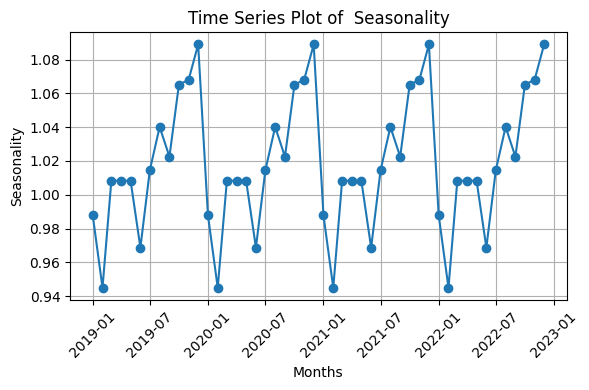

In [115]:
#seasonality calculation
df['month index']=df['date'].dt.month
df["Seasonality"] = df.groupby(['month index'])["kpi_val_sales_mn"].transform('mean')/df['kpi_val_sales_mn'].mean()
df.loc[df["date"].isin(["2020-04-01", "2020-05-01","2019-04-01", "2019-05-01","2021-04-01", "2021-05-01","2022-04-01", "2022-05-01"]), "Seasonality"] = df.loc[df["date"] == "2020-03-01", "Seasonality"].values[0]


# Create time series plots for each variable
plt.figure(figsize=(6, 4))
plt.plot(df["date"], df["Seasonality"], marker='o')
plt.title(f'Time Series Plot of  Seasonality')
plt.xlabel('Months')
plt.ylabel('Seasonality')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [116]:
def apl_transformation(series, adstock_rate=0.5, power=0.5):
    result = []
    for i in range(len(series)):
        if i == 0:
            result.append(series[i] ** power)
        else:
            result.append((series[i] + adstock_rate * result[i - 1]) ** power)
    return result

# Define specific adstock_rate and power values for each tactic from domain knowledge
tactic_params = {
    'newspaper_impressions': {'adstock_rate': 0.8, 'power': 0.6},
    'tv_total_grp': {'adstock_rate': 0.8, 'power': 0.4},
    'google_display_impressions_mn': {'adstock_rate': 0.7, 'power': 0.8},
    'youtube_impressions_mn': {'adstock_rate': 0.7, 'power': 0.6},
    'fb_ig_impressions_mn': {'adstock_rate': 0.7, 'power': 0.6},
    'jio_impressions_mn': {'adstock_rate': 0.7, 'power': 0.8},
    'hotstar_impressions_mn': {'adstock_rate': 0.7, 'power': 0.6},
    'whatsapp_clicks': {'adstock_rate': 0.4, 'power': 0.8},
    }

# Apply APL transformation using the specific parameters
for column, params in tactic_params.items():
    df[column] = apl_transformation(df[column], adstock_rate=params['adstock_rate'], power=params['power'])

In [117]:
x = [col for col in df.columns if ('spots' in col.lower() or 'clicks' in col.lower() or col in {'vol_sales_mn','wtd_dist_max','kpi_val_sales_mn','month index','whatsapp_impressions_mn','competition1_newspaper_impressions','competition2_newspaper_impressions','competition1_tv_total_grp','ventes_avenue_spends_mn'})]
x.remove('whatsapp_clicks')
x

['kpi_val_sales_mn',
 'vol_sales_mn',
 'wtd_dist_max',
 'tv_spots',
 'competition1_newspaper_impressions',
 'competition1_tv_total_grp',
 'competition1_tv_spots',
 'competition2_newspaper_impressions',
 'competition2_tv_spots',
 'google_display_clicks',
 'youtube_clicks',
 'fb_ig_clicks',
 'whatsapp_impressions_mn',
 'jio_clicks',
 'hotstar_clicks',
 'ventes_avenue_spends_mn',
 'month index']

In [118]:
# OLS-based MMM model
y = df['kpi_val_sales_mn']
X = df.drop(columns=['date']+ x)
X = sm.add_constant(X)

In [119]:
X.columns

Index(['const', 'num_dist_max', 'trade_promo_spends_mn',
       'consumer_promo_spends_mn', 'newspaper_impressions', 'tv_total_grp',
       'competition2_tv_total_grp_19', 'competition2_tv_total_grp_20',
       'competition2_tv_total_grp_21', 'competition2_tv_total_grp_22',
       'google_display_impressions_mn', 'youtube_impressions_mn',
       'fb_ig_impressions_mn', 'whatsapp_clicks', 'jio_impressions_mn',
       'hotstar_impressions_mn', 'Price', 'Seasonality'],
      dtype='object')

In [120]:
def constrained_regression_objective(coeffs, X, y):
    return np.sum((y-X.dot(coeffs))**2)

def constrained_regression_with_bounds(X, y):
    initial_guess = np.zeros(X.shape[1])
    bounds = [
        (4, None),         #const(positive)
        (1.18478625907066, 6.5),         #num_dist_max(positive)
        (1.76996690040081,1.76996690040081),         #trade_promo_spends_mn(positive)
        (1.50490303051089,1.50490303051089),         #consumer_promo_spends_mn(positive)
        (1.7,1.7),         # newspaper_impressions (positive)
        (2.77614883642085,2.77614883642085),         # TV (positive)
        (-0.195144447556406,-0.195144447556406),         # competition2_tv_total_grp_19 (negative)
        (-0.110987787119707,-0.110987787119707),         # competition2_tv_total_grp_20 (negative)
        (-0.0153247320436593,-0.0153247320436593),         # competition2_tv_total_grp_21 (negative)
        (-8,-0.01),         # competition2_tv_total_grp_22 (negative)
        (0.1, None),         # google_display_impressions_mn (positive)
        (0.276656772203308,0.276656772203308),         # youtube_impressions_mn (positive)
        (0.235890308608361,0.235890308608361),         # fb_ig_impressions_mn (positive)
        (0.000317486440385148, 0.000317486440385148),          # whatsapp_clicks (positive)
        (0.1743162436643,0.1743162436643),         # jio_impressions_mn (positive)
        (0.358995171375555,0.358995171375555),         # hotstar_impressions_mn (positive)
        (25,None),         # price (positive)
        (15, None)          # seasonality (positive)
    ]
    result = minimize(
        constrained_regression_objective,
        initial_guess,
        args=(X, y),
        bounds=bounds,
        method='L-BFGS-B')
    return result.x        # All coefficients

coeffs= constrained_regression_with_bounds(X.values, y.values)
y_pred = X.values.dot(coeffs)

In [121]:
variable_names = list(X.columns)
results_df = pd.DataFrame({
    'Variable': variable_names,
    'Constrained_Coeff': coeffs,
    'Expected_Sign': ['Positive','Positive','Positive','Positive','Positive','Positive','Negative','Negative','Negative','Negative','Positive','Positive','Positive','Positive',
                      'Positive','Positive','Positive','Positive']
})
print("\n=== REGRESSION RESULTS ===")
print(results_df.round(4))


=== REGRESSION RESULTS ===
                         Variable  Constrained_Coeff Expected_Sign
0                           const             4.0000      Positive
1                    num_dist_max             6.5000      Positive
2           trade_promo_spends_mn             1.7700      Positive
3        consumer_promo_spends_mn             1.5049      Positive
4           newspaper_impressions             1.7000      Positive
5                    tv_total_grp             2.7761      Positive
6    competition2_tv_total_grp_19            -0.1951      Negative
7    competition2_tv_total_grp_20            -0.1110      Negative
8    competition2_tv_total_grp_21            -0.0153      Negative
9    competition2_tv_total_grp_22            -0.0100      Negative
10  google_display_impressions_mn             0.1000      Positive
11         youtube_impressions_mn             0.2767      Positive
12           fb_ig_impressions_mn             0.2359      Positive
13                whatsapp_clicks 

In [122]:
# Calculate R-squared and Adjusted R-squared
r2=r2_score(y, y_pred)
n=len(y)
p=X.shape[1]-1
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2_constrained = adjusted_r2(r2, n, p)
r2, adj_r2_constrained

(0.8128118577983428, 0.7067385772174036)

In [123]:
mape = mean_absolute_percentage_error(y, y_pred)
mape

0.07701945903096297

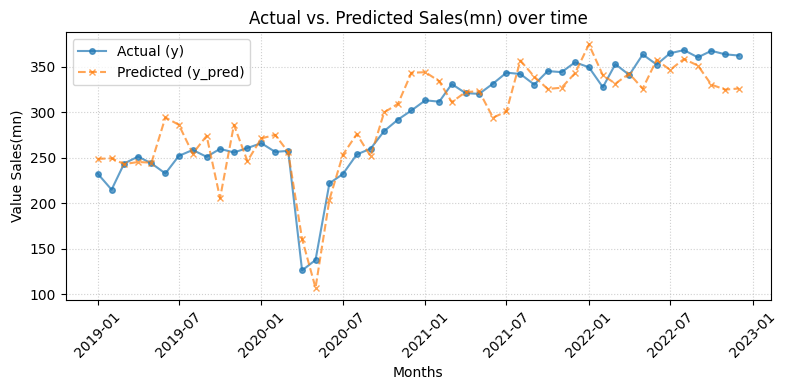

In [124]:
plt.figure(figsize=(8, 4))
# Plot actual values
plt.plot(df["date"], y, label='Actual (y)', marker='o', linestyle='-', markersize=4, alpha=0.7)
# Plot predicted values
plt.plot(df["date"], y_pred, label='Predicted (y_pred)', marker='x', linestyle='--', markersize=4, alpha=0.7)
plt.xlabel("Months")
plt.ylabel("Value Sales(mn)")
plt.title("Actual vs. Predicted Sales(mn) over time")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date formatting
plt.xticks(rotation=45)
plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()

In [125]:
# First, make sure your data is ready
print("X shape:", X.shape)
print("y shape:", y.shape)
print("coeffs shape:", coeffs.shape)


X shape: (48, 18)
y shape: (48,)
coeffs shape: (18,)


In [126]:
def create_excel_output(X, coeffs, output_filename='mmm_results.xlsx'):
    """
    Create Excel file with three tabs:
    1. Beta Coefficients
    2. X Values 
    3. Beta * X (contribution of each variable)
    """
    
    # Tab 1: Beta Coefficients
    beta_df = pd.DataFrame({
        'Variable': X.columns,
        'Beta_Coefficient': coeffs
    })
    
    # Tab 2: X Values (original data)
    x_values_df = X.copy()
    
    # Tab 3: Beta * X (contribution matrix)
    beta_x_df = X.copy()
    for i, col in enumerate(X.columns):
        beta_x_df[col] = X[col] * coeffs[i]
    
    # Write to Excel with multiple sheets
    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        # Write beta coefficients
        beta_df.to_excel(writer, sheet_name='Beta_Coefficients', index=False)
        
        # Write X values
        x_values_df.to_excel(writer, sheet_name='X_Values', index=True)
        
        # Write Beta * X contributions
        beta_x_df.to_excel(writer, sheet_name='Beta_X_Contributions', index=True)    
    return beta_df, x_values_df, beta_x_df

# Execute the function
beta_df, x_values_df, beta_x_df = create_excel_output(X, coeffs, 'mmm_model_results.xlsx')